In [5]:
!pip install torch torchvision pandas matplotlib pillow scikit-learn imbalanced-learn timm tqdm

import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from imblearn.over_sampling import RandomOverSampler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm
from tqdm import tqdm


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 11.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 11.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 11.4 MB/s  0:00:00 eta 0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 11.5 MB/s  0:00:01 eta 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 11.3 MB/s  0:00:00 eta 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [imbalanced-learn][matplotlib]n]


/opt/anaconda3/envs/vision/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
baseDir = "/Users/abdurrahman/Downloads/Skin_Cancer"  # <-- change
metaPath = os.path.join(baseDir, "HAM10000_metadata.csv")
device = torch.device("cpu")

imgSize = 299
batchSize = 8
epochs = 2       # start small on CPU, increase later
numWorkers = 0

os.makedirs("models", exist_ok=True)
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [7]:
classMap = {"akiec": 0, "bcc": 1, "bkl": 2,
            "df": 3, "mel": 4, "nv": 5, "vasc": 6}
indexToClass = {v: k for k, v in classMap.items()}
numClasses = 7

metaDf = pd.read_csv(metaPath)
metaDf["label"] = metaDf["dx"].map(classMap)


def findImgPath(imageId):
    p1 = os.path.join(baseDir, "HAM10000_images_part_1", f"{imageId}.jpg")
    p2 = os.path.join(baseDir, "HAM10000_images_part_2", f"{imageId}.jpg")
    if os.path.exists(p1):
        return p1
    if os.path.exists(p2):
        return p2
    return None


metaDf["imgPath"] = metaDf["image_id"].apply(findImgPath)
metaDf = metaDf.dropna(subset=["imgPath"]).reset_index(drop=True)
print("Images:", len(metaDf))

Images: 10015


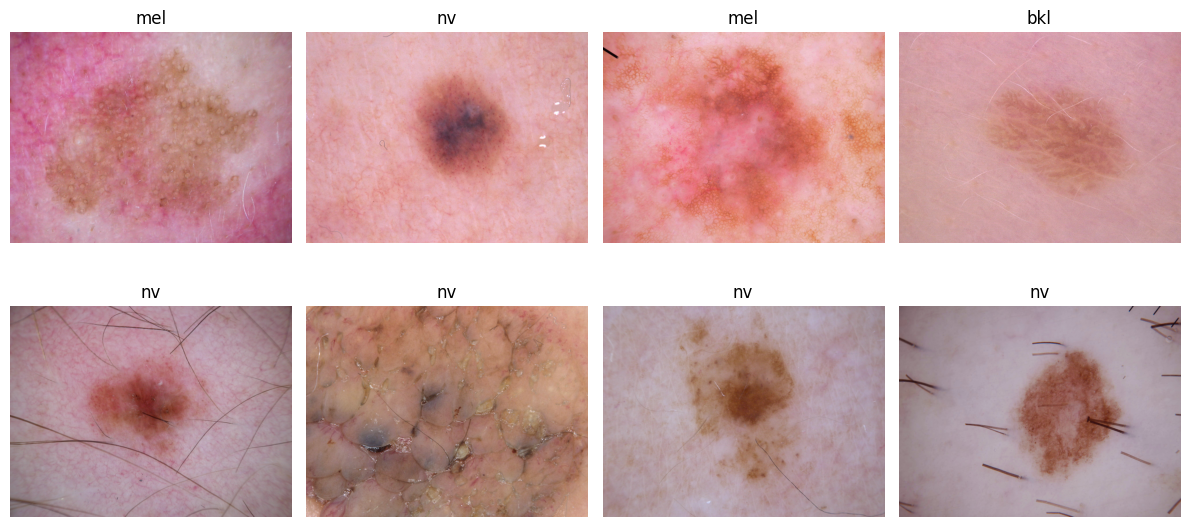

In [8]:
def showRandomImages(df, n=8):
    sampleDf = df.sample(
        n=min(n, len(df)), random_state=42).reset_index(drop=True)
    plt.figure(figsize=(12, 6))
    for i in range(len(sampleDf)):
        img = Image.open(sampleDf.loc[i, "imgPath"]).convert("RGB")
        lab = indexToClass[int(sampleDf.loc[i, "label"])]
        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        plt.title(lab)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


showRandomImages(metaDf, n=8)

In [9]:
trainDf, tempDf = train_test_split(
    metaDf, test_size=0.30, stratify=metaDf["label"], random_state=42)
valDf, testDf = train_test_split(
    tempDf, test_size=0.50, stratify=tempDf["label"], random_state=42)

ros = RandomOverSampler(random_state=42)
xRes, yRes = ros.fit_resample(trainDf[["imgPath"]], trainDf["label"])
trainBalDf = pd.concat(
    [xRes, pd.Series(yRes, name="label")], axis=1).reset_index(drop=True)
print("Balanced train:", len(trainBalDf))

Balanced train: 32851


In [10]:
class SkinDataset(Dataset):
    def __init__(self, df, tf):
        self.df = df.reset_index(drop=True)
        self.tf = tf

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df.loc[idx, "imgPath"]).convert("RGB")
        x = self.tf(img)
        y = int(self.df.loc[idx, "label"])
        return x, y


trainTf = transforms.Compose([
    transforms.Resize((imgSize, imgSize)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

evalTf = transforms.Compose([
    transforms.Resize((imgSize, imgSize)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

trainLoader = DataLoader(SkinDataset(trainBalDf, trainTf),
                         batch_size=batchSize, shuffle=True, num_workers=numWorkers)
valLoader = DataLoader(SkinDataset(
    valDf[["imgPath", "label"]], evalTf), batch_size=batchSize, shuffle=False, num_workers=numWorkers)
testLoader = DataLoader(SkinDataset(
    testDf[["imgPath", "label"]], evalTf), batch_size=batchSize, shuffle=False, num_workers=numWorkers)

In [11]:
class Cbam(nn.Module):
    def __init__(self, ch):
        super().__init__()
        mid = max(1, ch // 16)
        self.avgPool = nn.AdaptiveAvgPool2d(1)
        self.maxPool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(ch, mid, bias=False), nn.ReLU(), nn.Linear(mid, ch, bias=False))
        self.sig = nn.Sigmoid()
        self.sConv = nn.Conv2d(2, 1, 7, padding=3, bias=False)

    def forward(self, x):
        a = self.mlp(self.avgPool(x).flatten(1))
        m = self.mlp(self.maxPool(x).flatten(1))
        w = self.sig(a + m).unsqueeze(-1).unsqueeze(-1)
        x = x * w

        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)
        s = self.sig(self.sConv(torch.cat([avg, mx], dim=1)))
        return x * s

In [12]:
def buildCnn():
    return nn.Sequential(
        nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Linear(128, numClasses),
    ).to(device)


def buildTimm(modelName, useAttn=False):
    base = timm.create_model(
        modelName, pretrained=True, num_classes=numClasses)

    # freeze most to speed CPU
    for p in list(base.parameters())[:-20]:
        p.requires_grad = False

    if not useAttn:
        return base.to(device)

    class Wrap(nn.Module):
        def __init__(self, m):
            super().__init__()
            self.m = m
            self.cbam = Cbam(int(getattr(m, "num_features", 2048)))

        def forward(self, x):
            f = self.m.forward_features(x)
            if f.ndim == 4:
                f = self.cbam(f)
            return self.m.forward_head(f, pre_logits=False)

    return Wrap(base).to(device)


modelsToTrain = {
    "CNN": buildCnn(),
    "InceptionV3": buildTimm("inception_v3", useAttn=False),
    "InceptionV3_Attn": buildTimm("inception_v3", useAttn=True),
    "Xception": buildTimm("xception", useAttn=False),
    "Xception_Attn": buildTimm("xception", useAttn=True),
}

/opt/anaconda3/envs/vision/lib/python3.11/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


In [ ]:
criterion = nn.CrossEntropyLoss()


def trainModel(modelName, model):
    lr = 1e-3 if "Attn" in modelName else 3e-4
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    bestVal = 0.0
    for ep in range(epochs):
        model.train()
        for x, y in tqdm(trainLoader, desc=f"{modelName} ep {ep+1}/{epochs}"):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for x, y in valLoader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                pred = out.argmax(1)
                correct += int((pred == y).sum().item())
                total += int(y.size(0))
        valAcc = correct / max(total, 1)
        print("valAcc:", valAcc)

        if valAcc > bestVal:
            bestVal = valAcc
            torch.save(model.state_dict(), f"models/{modelName}_best.pth")

    return bestVal

In [ ]:
for modelName, model in modelsToTrain.items():
    print("\nTraining:", modelName)
    trainModel(modelName, model)


Training: CNN


CNN ep 1/2:  10%|▉         | 398/4107 [01:51<16:37,  3.72it/s]

In [ ]:
results = []

for modelName, model in modelsToTrain.items():
    model.load_state_dict(torch.load(
        f"models/{modelName}_best.pth", map_location=device))
    model.eval()

    yTrue = []
    yPred = []
    with torch.no_grad():
        for x, y in testLoader:
            x = x.to(device)
            out = model(x)
            pred = out.argmax(1).cpu().numpy().tolist()
            yPred.extend(pred)
            yTrue.extend(y.numpy().tolist())

    acc = float(np.mean(np.array(yTrue) == np.array(yPred)))
    macroF1 = float(f1_score(yTrue, yPred, average="macro"))
    results.append({"model": modelName, "testAcc": acc, "macroF1": macroF1})

    print("\n", modelName, "acc:", acc, "macroF1:", macroF1)
    print(classification_report(yTrue, yPred, target_names=[
          indexToClass[i] for i in range(numClasses)]))

resultDf = pd.DataFrame(results).sort_values(
    "testAcc", ascending=False).reset_index(drop=True)
print("\nFinal results:")
print(resultDf)

In [ ]:
plt.figure(figsize=(10, 4))
plt.bar(resultDf["model"], resultDf["testAcc"])
plt.title("Test Accuracy (All Models)")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()